# Exploratory Data Analysis (EDA) v2

El objetivo de este notebook es ampliar el análisis exploratorio del dataset enriquecido DOGE/USDT, incorporando no solo visualizaciones básicas, sino también análisis de regímenes de mercado, volatilidad, patrones temporales, stationarity y relaciones entre features y targets.

Este EDA se realiza sobre el dataset generado tras la fase de feature engineering, ya que el objetivo principal es estudiar las variables que alimentarán los modelos supervisados y las estrategias de backtesting posteriores.


In [1]:
# ============================================================
# 03 - Exploratory Data Analysis (EDA v2)
# DOGE/USDT 5m enriched dataset
# Carga el dataset procesado y configura las librerías necesarias para el análisis exploratorio ampliado.
# ============================================================

import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["open_time", "close_time"]
)

df = df.sort_values("open_time").reset_index(drop=True)

print("Dataset loaded")
print("Shape:", df.shape)
print("Date range:", df["open_time"].min(), "->", df["open_time"].max())

display(df.head())


Dataset loaded
Shape: (712257, 54)
Date range: 2019-07-07 11:50:00 -> 2026-05-23 10:10:00


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,return_prev_1,log_return_prev_1,sma_20,ema_10,ema_50,ema_200,ema10_ema50_ratio,ema50_ema200_ratio,sma20_ema50_ratio,volatility_1h,zscore_close_1h,rsi_14,macd,macd_signal,macd_hist,bb_mid,bb_upper,bb_lower,bb_width,bb_percent,atr_14,future_close_1,future_return_1,up_1,future_close_3,future_return_3,up_3,future_close_6,future_return_6,up_6,future_close_12,future_return_12,up_12,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-07 11:50:00,0.003496,0.003503,0.003492,0.003492,145316.0,2019-07-07 11:54:59.999,508.053883,14,37501.0,131.249266,-0.001544,-0.001545,0.003516,0.003502,0.003516,0.003518,0.996053,0.999417,1.000207,0.003406,-0.709884,31.952191,-0.000009,-0.000007,-2.136674e-06,0.003516,0.003560,0.003472,0.025044,0.224510,0.000018,0.003500,0.002405,1,0.003498,0.001775,1,0.003497,0.001403,1,0.003481,-0.003150,0,0.402795,0.003365,0.00368,0.036312,0.053837,0.0,0.0,30.0,0.0,30.0
1,2019-07-07 11:55:00,0.003494,0.003500,0.003492,0.003500,1727089.0,2019-07-07 11:59:59.999,6040.557436,21,1017415.0,3559.587012,0.002405,0.002403,0.003514,0.003501,0.003515,0.003517,0.996156,0.999297,0.999672,0.003522,0.239159,37.743191,-0.000009,-0.000008,-1.357495e-06,0.003514,0.003555,0.003472,0.023658,0.338985,0.000019,0.003505,0.001257,1,0.003505,0.001314,1,0.003480,-0.005828,0,0.003486,-0.004114,0,0.429479,0.003365,0.00368,0.038624,0.051308,0.0,0.0,30.0,0.0,30.0
2,2019-07-07 12:00:00,0.003497,0.003505,0.003491,0.003505,2644825.0,2019-07-07 12:04:59.999,9268.834500,26,811589.0,2844.119320,0.001257,0.001256,0.003512,0.003502,0.003515,0.003517,0.996443,0.999220,0.999271,0.003328,0.953899,40.944272,-0.000008,-0.000008,-4.475038e-07,0.003512,0.003552,0.003472,0.022608,0.409572,0.000019,0.003498,-0.001883,0,0.003500,-0.001484,0,0.003481,-0.006705,0,0.003490,-0.004109,0,0.443456,0.003365,0.00368,0.039831,0.049989,0.0,0.0,30.0,0.0,30.0
3,2019-07-07 12:05:00,0.003505,0.003505,0.003487,0.003498,1335881.0,2019-07-07 12:09:59.999,4672.287479,35,1267575.0,4433.848056,-0.001883,-0.001885,0.003510,0.003501,0.003514,0.003517,0.996426,0.999092,0.998785,0.003006,0.035911,38.410104,-0.000008,-0.000008,-2.041991e-07,0.003510,0.003547,0.003473,0.021019,0.345059,0.000020,0.003505,0.001944,1,0.003497,-0.000372,0,0.003476,-0.006403,0,0.003497,-0.000314,0,0.422490,0.003365,0.00368,0.038020,0.051970,0.0,0.0,30.0,0.0,30.0
4,2019-07-07 12:10:00,0.003498,0.003516,0.003498,0.003505,5442392.0,2019-07-07 12:14:59.999,19046.081219,64,5027347.0,17589.673086,0.001944,0.001942,0.003508,0.003502,0.003514,0.003517,0.996715,0.999027,0.998375,0.003031,0.865004,46.762590,-0.000007,-0.000008,4.641070e-07,0.003508,0.003542,0.003474,0.019309,0.458071,0.000020,0.003500,-0.001541,0,0.003480,-0.007133,0,0.003484,-0.006020,0,0.003491,-0.004137,0,0.444091,0.003365,0.00368,0.039886,0.049929,0.0,0.0,30.0,0.0,30.0


In [2]:
# ============================================================
# General overview
# ============================================================

print(df.info())

display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712257 entries, 0 to 712256
Data columns (total 54 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   open_time                       712257 non-null  datetime64[ns]
 1   open                            712257 non-null  float64       
 2   high                            712257 non-null  float64       
 3   low                             712257 non-null  float64       
 4   close                           712257 non-null  float64       
 5   volume                          712257 non-null  float64       
 6   close_time                      712257 non-null  datetime64[ns]
 7   quote_asset_volume              712257 non-null  float64       
 8   number_of_trades                712257 non-null  int64         
 9   taker_buy_base_asset_volume     712257 non-null  float64       
 10  taker_buy_quote_asset_volume    712257 non-null  float64

,count,mean,min,25%,50%,75%,max,std
open_time,712257,2022-12-26 15:58:13.841687040,2019-07-07 11:50:00,2021-04-13 19:00:00,2022-12-31 18:40:00,2024-09-12 03:30:00,2026-05-23 10:10:00,NaN
open,712257.0,0.1163,0.001219,0.05883,0.09186,0.16787,0.73623,0.100505
high,712257.0,0.11658,0.001238,0.058913,0.092,0.1682,0.73995,0.100856
low,712257.0,0.116013,0.001135,0.05874,0.09171,0.1675,0.72743,0.100143
close,712257.0,0.1163,0.001218,0.05883,0.09186,0.16787,0.73623,0.100506
volume,712257.0,6024997.687185,0.0,792266.0,1987918.0,4872266.0,2174740295.0,22423356.656906
close_time,712257,2022-12-26 16:03:13.840681984,2019-07-07 11:54:59.999000,2021-04-13 19:04:59.999000064,2022-12-31 18:44:59.999000064,2024-09-12 03:34:59.999000064,2026-05-23 10:14:59.999000,NaN
quote_asset_volume,712257.0,951921.817801,0.0,39297.5551,193823.2584,634432.07488,378267072.445506,3983933.663253
number_of_trades,712257.0,2149.630437,0.0,132.0,604.0,2083.0,385041.0,5343.349066
taker_buy_base_asset_volume,712257.0,2987574.552706,0.0,348770.0,949260.0,2410744.0,1087817541.0,11292050.247407


## Conclusiones - Visión general del dataset

El conjunto de datos final contiene cientos de miles de observaciones temporales correspondientes al par DOGE/USDT en intervalos de 5 minutos, cubriendo varios años de histórico de mercado cripto.

El dataset presenta una estructura consistente y completa, sin valores nulos tras el proceso de limpieza y generación de variables derivadas, lo que permite su utilización directa en tareas de modelado y análisis temporal.

A nivel descriptivo, pueden observarse varias características relevantes:

- El mercado presenta una elevada dispersión en variables relacionadas con volumen y número de operaciones, reflejando periodos de actividad muy heterogéneos y episodios de alta volatilidad.

- Los retornos históricos calculados mediante variables laggeadas como return_prev_1 y log_return_prev_1 son extremadamente pequeños y cercanos a cero, como es habitual en series financieras de alta frecuencia, aunque acompañados de eventos extremos ocasionales.

- Los indicadores técnicos generados muestran distribuciones coherentes y escalas muy diferentes entre sí, aspecto relevante para futuras fases de normalización y entrenamiento de modelos.

- La presencia de valores extremos y colas pesadas en determinadas variables sugiere que el comportamiento del mercado no sigue una distribución normal clásica.

En conjunto, el dataset proporciona una base sólida y suficientemente rica para la aplicación de técnicas de machine learning y análisis cuantitativo sobre series temporales financieras.

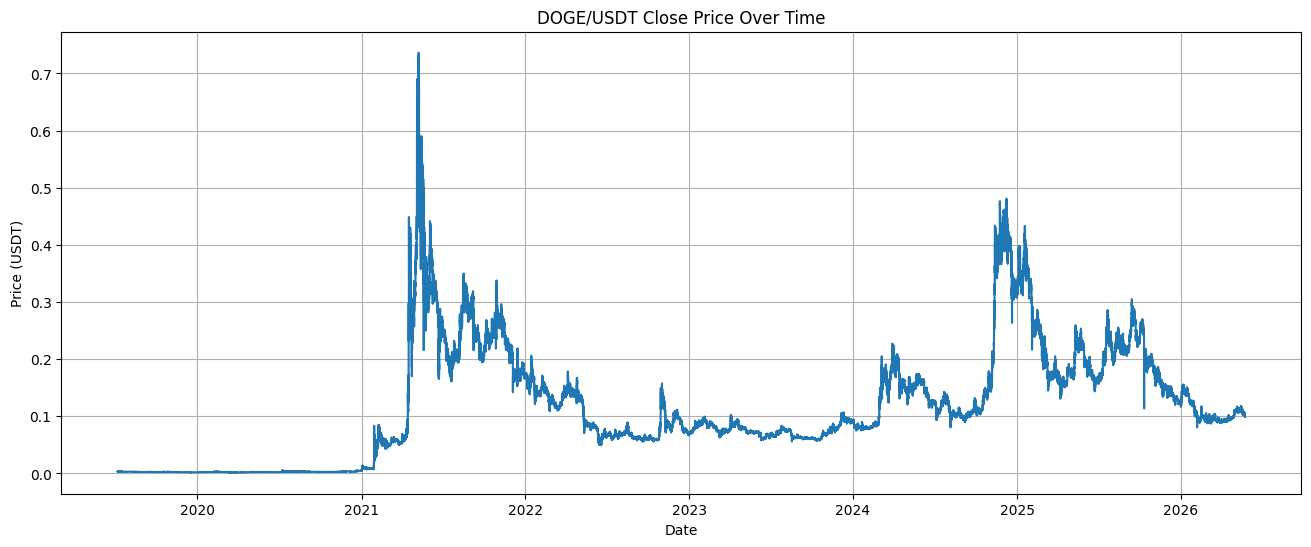

In [3]:
# ============================================================
# DOGE price evolution
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(df["open_time"], df["close"])

plt.title("DOGE/USDT Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")

plt.grid(True)

plt.show()

## Conclusiones – Evolución temporal del precio

La evolución histórica del precio de DOGE/USDT muestra claramente distintos regímenes de mercado, incluyendo periodos de estabilidad relativa, fases de crecimiento acelerado y episodios de elevada volatilidad.

Destacan especialmente los movimientos explosivos observados durante determinados ciclos alcistas del mercado de criptomonedas, caracterizados por fuertes incrementos de precio acompañados de aumentos significativos en la actividad de mercado.

Este comportamiento confirma la naturaleza altamente especulativa del activo y justifica la utilización de técnicas de modelado capaces de capturar dinámicas no lineales y cambios abruptos en las condiciones del mercado.

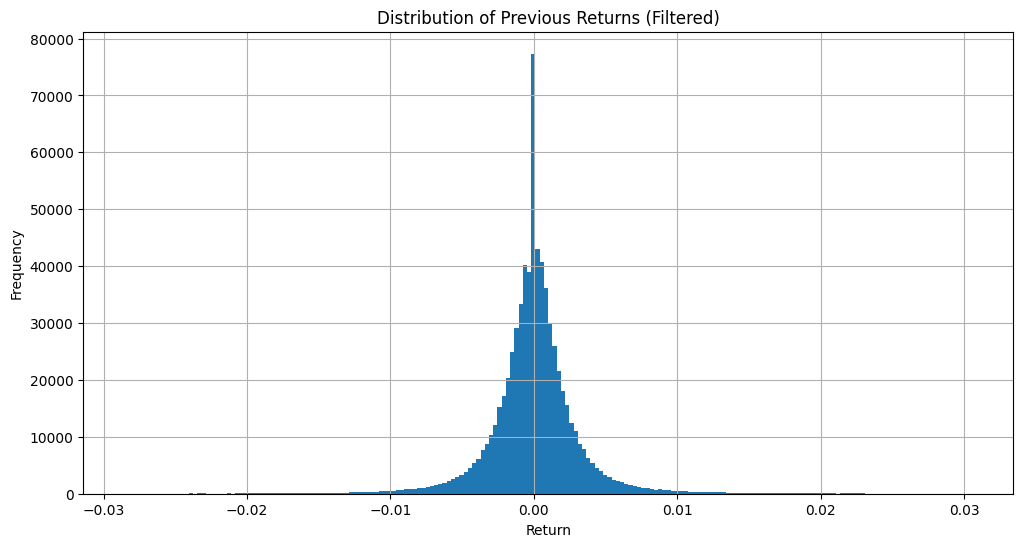

Original min/max: -0.4316399420550477 0.3084302729758541
Filtered min/max: -0.02849857950919741 0.030532198634245132
Skewness: 0.20243792984965978
Kurtosis: 398.0696039625226


In [4]:
# ============================================================
# Returns distribution (zoomed)
# ============================================================

returns = df["return_prev_1"].dropna()

# Remove extreme outliers for visualization only
lower = returns.quantile(0.001)
upper = returns.quantile(0.999)

returns_filtered = returns[
    (returns >= lower) &
    (returns <= upper)
]

plt.figure(figsize=(12, 6))

plt.hist(
    returns_filtered,
    bins=200
)

plt.title("Distribution of Previous Returns (Filtered)")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

print("Original min/max:", returns.min(), returns.max())
print("Filtered min/max:", lower, upper)
print("Skewness:", returns.skew())
print("Kurtosis:", returns.kurtosis())

## Conclusiones – Distribución de retornos

La distribución de los retornos a corto plazo presenta una fuerte concentración alrededor de cero, característica típica de los mercados financieros de alta frecuencia.

Sin embargo, el análisis estadístico muestra una curtosis extremadamente elevada, indicando la presencia de colas pesadas y eventos extremos significativamente más frecuentes de lo que cabría esperar bajo una distribución normal.

Asimismo, la ligera asimetría positiva observada refleja cierta inclinación hacia movimientos alcistas más pronunciados.

Estos resultados evidencian que el mercado de criptomonedas presenta un comportamiento altamente no gaussiano, aspecto especialmente relevante para el diseño de modelos predictivos robustos y estrategias de gestión de riesgo.

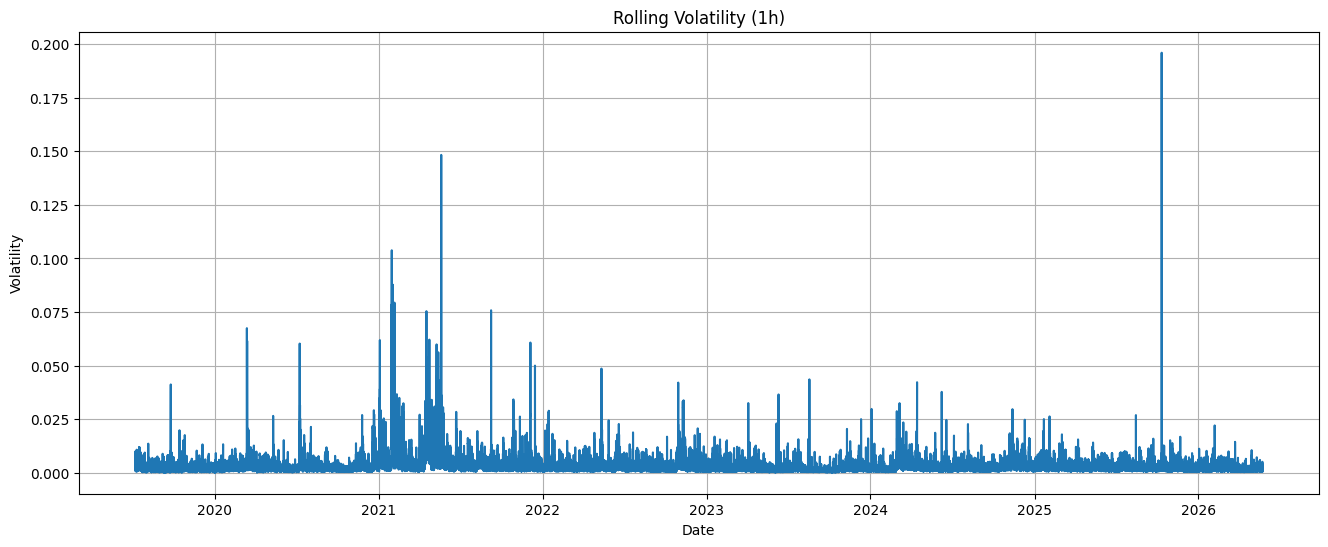

In [5]:
# ============================================================
# Volatility over time
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    df["open_time"],
    df["volatility_1h"]
)

plt.title("Rolling Volatility (1h)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## Conclusiones – Volatilidad temporal

El análisis de la volatilidad temporal muestra la existencia de periodos claramente diferenciados de estabilidad y turbulencia en el mercado.

Durante determinadas fases del ciclo de mercado se observan incrementos abruptos de volatilidad, coincidiendo habitualmente con eventos especulativos, movimientos de fuerte momentum o episodios de alta incertidumbre.

La naturaleza no estacionaria de la volatilidad constituye uno de los principales desafíos en el modelado de series financieras y justifica el uso de variables dinámicas adaptativas dentro del pipeline de machine learning.

Además, este comportamiento refuerza la importancia de incorporar mecanismos de gestión de riesgo y filtros de volatilidad en futuras estrategias de trading automatizado.

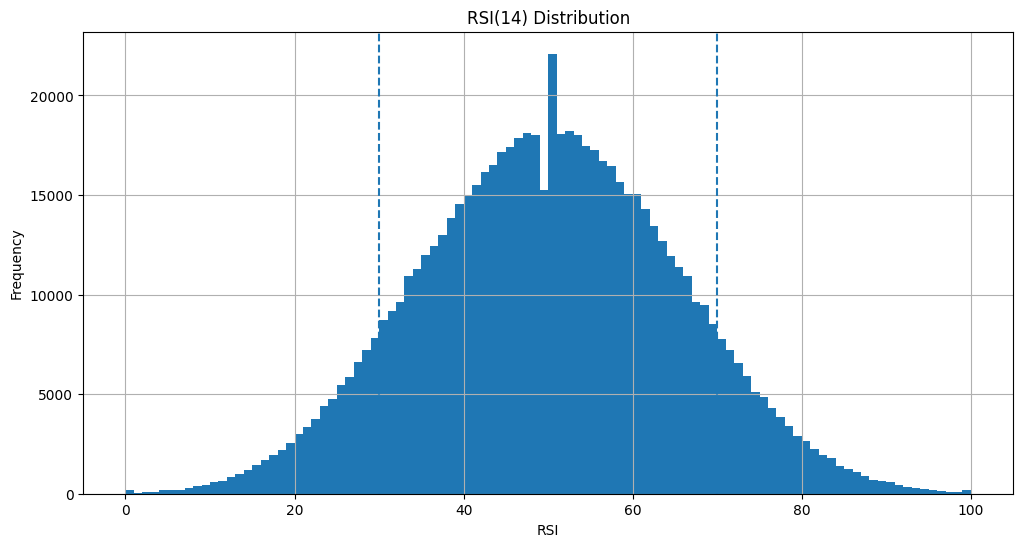

In [6]:
# ============================================================
# RSI distribution
# ============================================================

plt.figure(figsize=(12, 6))

plt.hist(
    df["rsi_14"].dropna(),
    bins=100
)

plt.axvline(30, linestyle="--")
plt.axvline(70, linestyle="--")

plt.title("RSI(14) Distribution")
plt.xlabel("RSI")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Conclusiones – Distribución del RSI

La distribución del indicador RSI muestra una fuerte concentración en valores intermedios, especialmente entre 40 y 60 puntos, indicando que el mercado permanece gran parte del tiempo en situaciones relativamente neutrales.

Los valores extremos asociados tradicionalmente a sobrecompra (>70) y sobreventa (<30) aparecen con menor frecuencia, aunque suelen coincidir con periodos de elevada volatilidad o movimientos impulsivos del mercado.

Este comportamiento confirma que el RSI puede aportar información útil como variable de contexto dentro de modelos predictivos, aunque probablemente resulte insuficiente como señal aislada de trading.

up_1
0    0.529937
1    0.470063
Name: proportion, dtype: float64


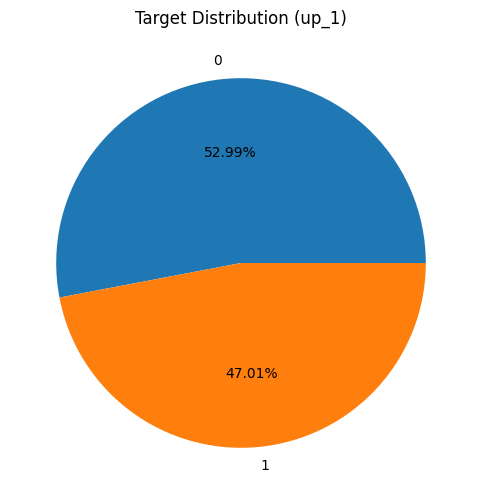

In [7]:
# ============================================================
# Target balance
# ============================================================

target_counts = df["up_1"].value_counts(normalize=True)

print(target_counts)

plt.figure(figsize=(6, 6))

plt.pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.2f%%"
)

plt.title("Target Distribution (up_1)")

plt.show()

## Conclusiones – Balance de clases objetivo

La variable objetivo binaria up_1, construida a partir de retornos futuros (future_return_1), presenta una distribución relativamente equilibrada entre movimientos alcistas y bajistas.

Este aspecto resulta especialmente importante desde el punto de vista del aprendizaje supervisado, ya que reduce el riesgo de sesgos extremos durante el entrenamiento de modelos de clasificación.

No obstante, incluso en escenarios aparentemente balanceados, las pequeñas diferencias porcentuales pueden amplificarse durante el entrenamiento y afectar al comportamiento final de los modelos predictivos.

Por ello, será importante monitorizar métricas adicionales más allá de la accuracy tradicional, como precision, recall, F1-score o métricas financieras derivadas del backtesting.

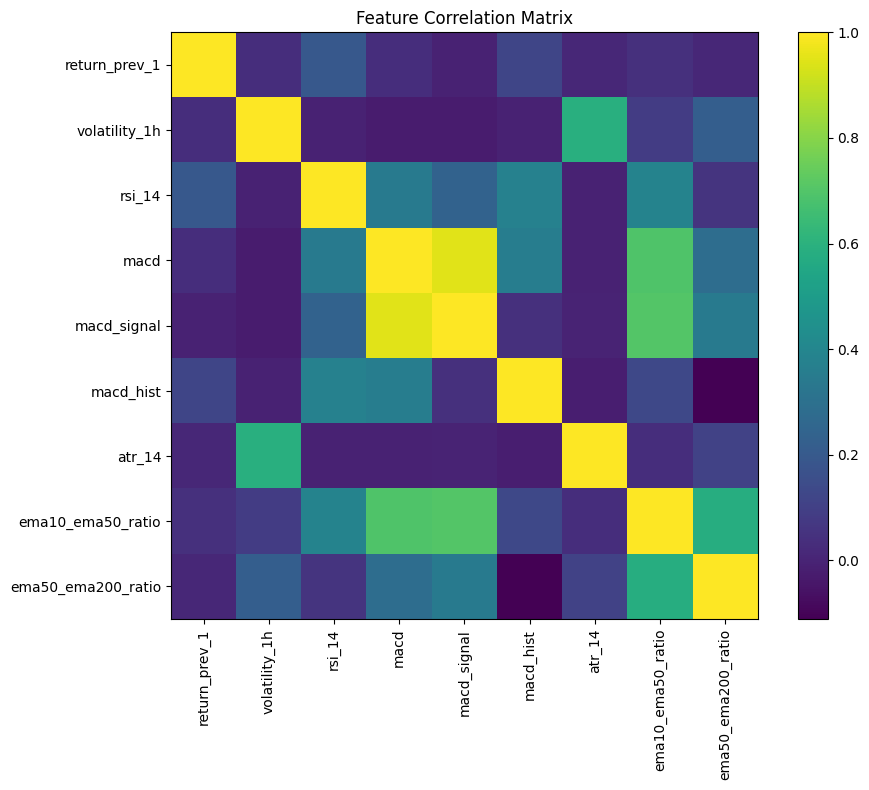

In [8]:
# ============================================================
# Correlation matrix
# ============================================================
feature_cols = [
    "return_prev_1",
    "volatility_1h",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "atr_14",
    "ema10_ema50_ratio",
    "ema50_ema200_ratio"
]

corr = df[feature_cols].corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## Conclusiones – Matriz de correlación

La matriz de correlación permite identificar relaciones lineales entre las distintas variables derivadas utilizadas en el proyecto.

Algunos indicadores muestran correlaciones elevadas debido a que comparten información subyacente relacionada con tendencia o momentum, como ocurre entre determinadas medias móviles o componentes del MACD.

Por otro lado, varias variables presentan correlaciones moderadas o bajas, indicando que aportan información parcialmente complementaria al sistema.

Este análisis resulta especialmente útil para:

- Detectar posibles problemas de multicolinealidad.
- Reducir redundancia entre variables.
- Seleccionar características relevantes.
- Mejorar la interpretabilidad y estabilidad de los modelos.

En fases posteriores del proyecto, este análisis podrá complementarse con técnicas adicionales de selección de variables y reducción de dimensionalidad.

## Ampliación

Las secciones anteriores permiten una primera revisión del dataset enriquecido. A continuación se amplía el análisis para estudiar propiedades especialmente relevantes en series financieras: evolución por regímenes de mercado, comportamiento agregado por año, posibles patrones de seasonality, stationarity, autocorrelación y relación entre features y targets.

En este contexto conviene distinguir dos conceptos distintos que suelen confundirse en castellano:

- **Seasonality (estacionalidad)**: presencia de patrones que se repiten en intervalos temporales concretos, como horas del día, días de la semana o meses.
- **Stationarity (estacionariedad)**: propiedad estadística por la cual una serie mantiene media, varianza y estructura temporal relativamente estables a lo largo del tiempo.

En mercados de criptomonedas pueden existir ciclos alcistas y bajistas muy marcados, pero eso no implica necesariamente seasonality estricta. Por ello, el análisis combina una exploración visual de ciclos de mercado con pruebas estadísticas sobre stationarity y patrones temporales.


In [9]:
# ============================================================
# Daily aggregation for long-term analysis
# Construye una vista diaria del dataset para analizar ciclos, drawdown y volatilidad sin trabajar directamente con todas las velas de 5 minutos.
# ============================================================

df_eda = df.copy()
df_eda["abs_return_prev_1"] = df_eda["return_prev_1"].abs()

daily = (
    df_eda
    .set_index("open_time")
    .resample("1D")
    .agg(
        close=("close", "last"),
        high=("high", "max"),
        low=("low", "min"),
        volume=("volume", "sum"),
        mean_5m_return=("return_prev_1", "mean"),
        mean_abs_5m_return=("abs_return_prev_1", "mean"),
        mean_volatility_1h=("volatility_1h", "mean"),
        candles=("close", "size")
    )
    .dropna(subset=["close"])
)

daily["daily_return"] = daily["close"].pct_change()
daily["daily_log_return"] = np.log(daily["close"] / daily["close"].shift(1))
daily["rolling_30d_return"] = daily["close"] / daily["close"].shift(30) - 1
daily["rolling_30d_volatility"] = daily["daily_log_return"].rolling(30).std()
daily["rolling_max_close"] = daily["close"].cummax()
daily["drawdown"] = daily["close"] / daily["rolling_max_close"] - 1

print("Daily dataset shape:", daily.shape)
print("Daily date range:", daily.index.min(), "->", daily.index.max())

display(daily.head())
display(daily.tail())


Daily dataset shape: (2495, 14)
Daily date range: 2019-07-07 00:00:00 -> 2026-05-23 00:00:00


,close,high,low,volume,mean_5m_return,mean_abs_5m_return,mean_volatility_1h,candles,daily_return,daily_log_return,rolling_30d_return,rolling_30d_volatility,rolling_max_close,drawdown
open_time,,,,,,,,,,,,,,
2019-07-07,0.003538,0.003650,0.003440,257045400.0,0.000086,0.002505,0.003477,146,NaN,NaN,NaN,NaN,0.003538,0.000000
2019-07-08,0.003458,0.003562,0.003400,308445688.0,-0.000075,0.002002,0.002631,288,-0.022529,-0.022786,NaN,NaN,0.003538,-0.022529
2019-07-09,0.003455,0.003582,0.003356,253375582.0,0.000004,0.002414,0.003415,288,-0.001012,-0.001013,NaN,NaN,0.003538,-0.023518
2019-07-10,0.003342,0.003529,0.003251,241274866.0,-0.000109,0.002283,0.003041,288,-0.032537,-0.033078,NaN,NaN,0.003538,-0.055290
2019-07-11,0.003209,0.003340,0.003091,202811394.0,-0.000133,0.002872,0.003705,288,-0.039825,-0.040640,NaN,NaN,0.003538,-0.092913


,close,high,low,volume,mean_5m_return,mean_abs_5m_return,mean_volatility_1h,candles,daily_return,daily_log_return,rolling_30d_return,rolling_30d_volatility,rolling_max_close,drawdown
open_time,,,,,,,,,,,,,,
2026-05-19,0.10300,0.10554,0.10266,423915585.0,-0.000058,0.001136,0.001418,288,-0.016894,-0.017038,0.107289,0.022255,0.68982,-0.850686
2026-05-20,0.10371,0.10497,0.10190,455852701.0,0.000025,0.001026,0.001352,288,0.006893,0.006870,0.089276,0.021949,0.68982,-0.849656
2026-05-21,0.10568,0.10652,0.10367,605897147.0,0.000067,0.001169,0.001534,288,0.018995,0.018817,0.110317,0.022131,0.68982,-0.846801
2026-05-22,0.10234,0.10682,0.10152,547931305.0,-0.000110,0.001128,0.001381,288,-0.031605,-0.032115,0.069942,0.023062,0.68982,-0.851642
2026-05-23,0.09955,0.10238,0.09736,511426925.0,-0.000223,0.001070,0.001694,123,-0.027262,-0.027641,0.024810,0.023548,0.68982,-0.855687


## Conclusiones - Agregación diaria

La agregación diaria permite analizar patrones de largo plazo de forma más interpretable que la serie original de 5 minutos. Esta vista resulta útil para estudiar bull runs, drawdowns y cambios de régimen sin perder la trazabilidad del dataset original.

PENDIENTE DE RESULTADO: tras ejecutar el notebook, revisar si existen días incompletos, outliers de volumen o periodos con número anómalo de velas antes de usar la vista diaria como apoyo en la memoria.


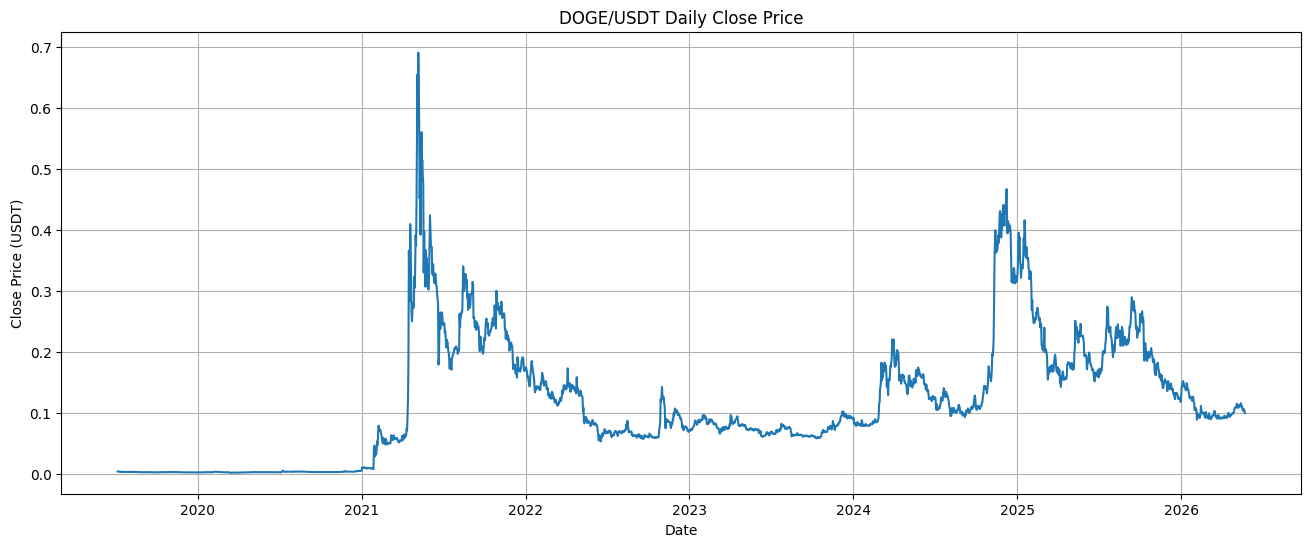

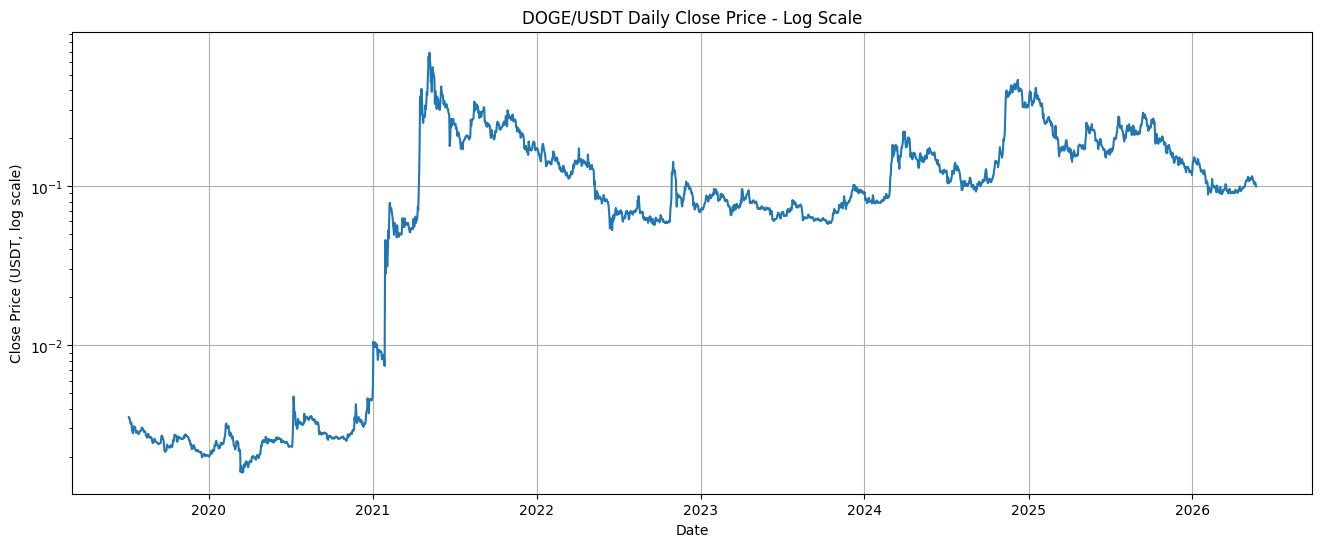

In [10]:
# ============================================================
# Long-term price evolution with logarithmic scale
# Visualiza el precio en escala lineal y logarítmica para interpretar mejor los grandes ciclos alcistas y bajistas.
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(daily.index, daily["close"])
plt.title("DOGE/USDT Daily Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price (USDT)")
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 6))
plt.plot(daily.index, daily["close"])
plt.yscale("log")
plt.title("DOGE/USDT Daily Close Price - Log Scale")
plt.xlabel("Date")
plt.ylabel("Close Price (USDT, log scale)")
plt.grid(True)
plt.show()


## Conclusiones - Ciclos de precio y escala logarítmica

La evolución del precio debe interpretarse con cautela porque DOGE presenta movimientos de magnitud muy distinta a lo largo del periodo analizado. La escala lineal permite observar el impacto visual de los grandes bull runs, mientras que la escala logarítmica facilita comparar cambios relativos entre periodos con niveles de precio muy diferentes.

PENDIENTE DE RESULTADO: describir los principales tramos observados tras ejecutar la celda, especialmente los periodos de crecimiento explosivo, correcciones posteriores y fases laterales prolongadas.


,num_days,first_close,last_close,yearly_return,min_close,max_close,mean_daily_volume,mean_abs_daily_return,daily_log_return_volatility
year,,,,,,,,,
2019,175,0.003538,0.002014,-0.430845,0.001977,0.003538,1.345533e+08,0.018945,0.027351
2020,358,0.002024,0.004671,1.307187,0.001582,0.004766,7.076293e+08,0.028680,0.050636
2021,359,0.005680,0.170300,28.982394,0.005680,0.689820,5.025957e+09,0.077067,0.136381
2022,365,0.173200,0.070250,-0.594400,0.052900,0.184500,1.313147e+09,0.037051,0.055402
2023,364,0.070240,0.089550,0.274915,0.057880,0.101860,1.103627e+09,0.022659,0.032270
2024,366,0.091990,0.316000,2.435156,0.077950,0.466350,1.969490e+09,0.038147,0.052528
2025,365,0.325130,0.117470,-0.638698,0.117470,0.415250,1.289631e+09,0.035991,0.048970
2026,143,0.126830,0.099550,-0.215091,0.088490,0.151710,9.621169e+08,0.026234,0.037524


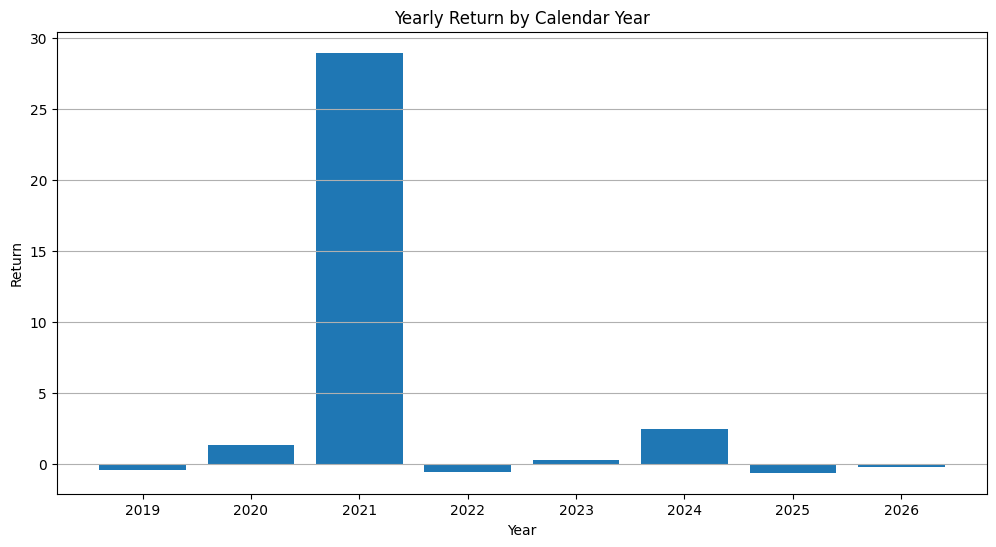

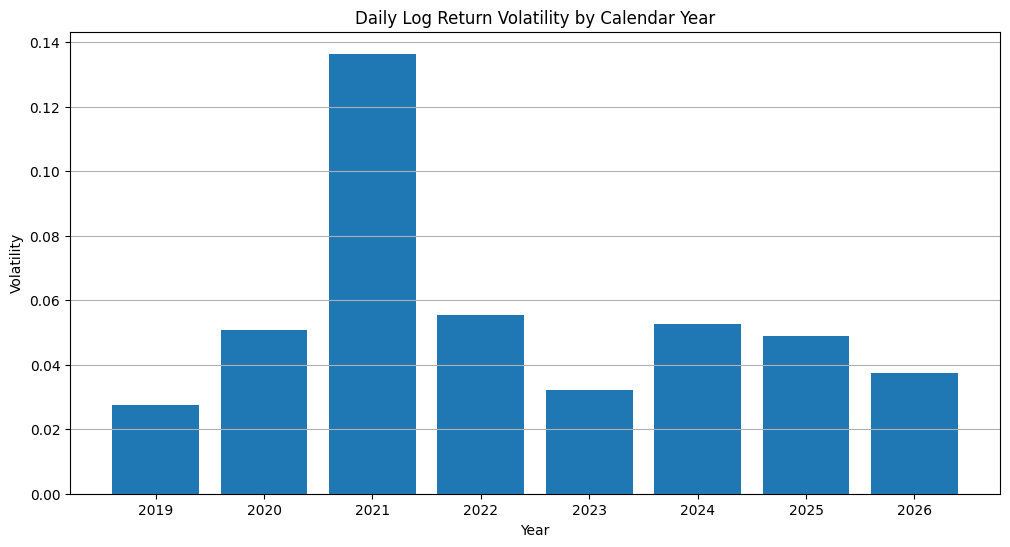

In [11]:
# ============================================================
# Yearly market summary
# Resume el comportamiento anual del activo para identificar regímenes de mercado y cambios estructurales entre periodos.
# ============================================================

yearly = daily.copy()
yearly["year"] = yearly.index.year

first_close = yearly.groupby("year")["close"].first()
last_close = yearly.groupby("year")["close"].last()
max_close = yearly.groupby("year")["close"].max()
min_close = yearly.groupby("year")["close"].min()
mean_volume = yearly.groupby("year")["volume"].mean()
mean_abs_return = yearly.groupby("year")["daily_return"].apply(lambda s: s.abs().mean())
volatility = yearly.groupby("year")["daily_log_return"].std()
num_days = yearly.groupby("year")["close"].size()

yearly_summary = pd.DataFrame({
    "num_days": num_days,
    "first_close": first_close,
    "last_close": last_close,
    "yearly_return": last_close / first_close - 1,
    "min_close": min_close,
    "max_close": max_close,
    "mean_daily_volume": mean_volume,
    "mean_abs_daily_return": mean_abs_return,
    "daily_log_return_volatility": volatility
})

display(yearly_summary)

plt.figure(figsize=(12, 6))
plt.bar(yearly_summary.index.astype(str), yearly_summary["yearly_return"])
plt.title("Yearly Return by Calendar Year")
plt.xlabel("Year")
plt.ylabel("Return")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(yearly_summary.index.astype(str), yearly_summary["daily_log_return_volatility"])
plt.title("Daily Log Return Volatility by Calendar Year")
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.grid(True, axis="y")
plt.show()


## Conclusiones - Resumen anual

El resumen anual permite separar el análisis por etapas de mercado. En activos cripto como DOGE, esta separación es especialmente útil porque el comportamiento de un año de fuerte expansión especulativa puede ser muy distinto al de un año lateral o bajista.

PENDIENTE DE RESULTADO: identificar qué años concentran mayor retorno, mayor volatilidad y mayor volumen medio. Esta información puede reforzar la idea de que el modelo debe evaluarse con particiones temporales y no con mezclas aleatorias del dataset.


Maximum drawdown: -0.9233133281145807
Maximum drawdown date: 2022-06-18 00:00:00


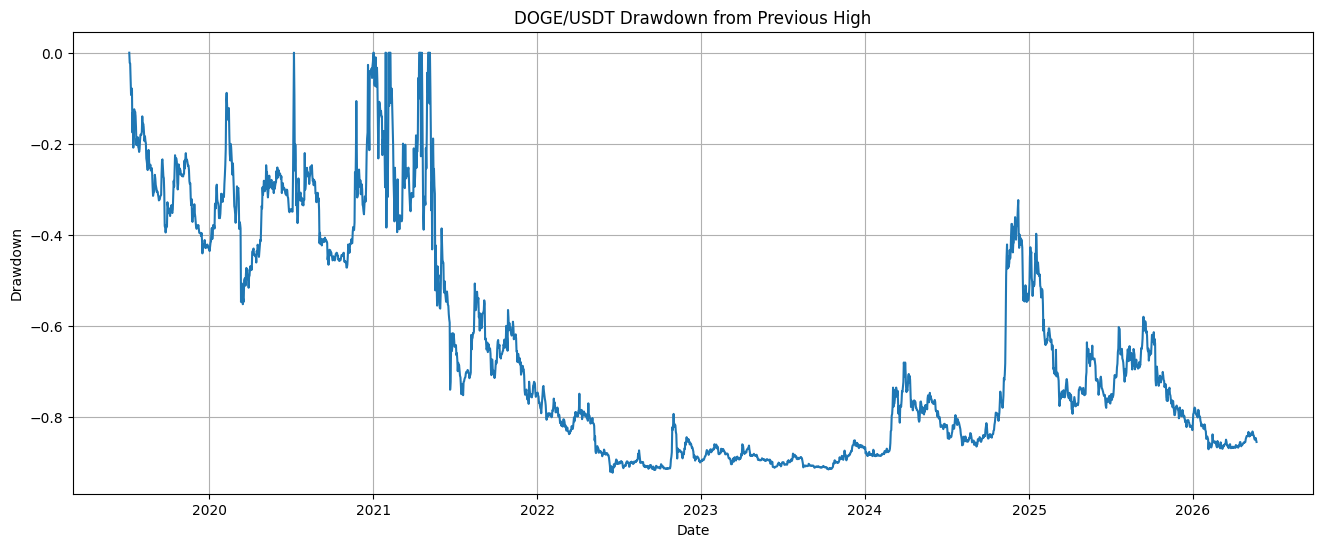

In [12]:
# ============================================================
# Drawdown analysis
# Calcula la caída relativa desde máximos previos para visualizar fases de pérdida acumulada tras bull runs.
# ============================================================

max_drawdown = daily["drawdown"].min()
max_drawdown_date = daily["drawdown"].idxmin()

print("Maximum drawdown:", max_drawdown)
print("Maximum drawdown date:", max_drawdown_date)

plt.figure(figsize=(16, 6))
plt.plot(daily.index, daily["drawdown"])
plt.title("DOGE/USDT Drawdown from Previous High")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()


## Conclusiones - Drawdown del activo

El drawdown del precio permite observar la magnitud de las caídas sufridas desde máximos anteriores. Este análisis es relevante porque un sistema de trading no solo debe buscar rentabilidad, sino también limitar periodos de pérdida acumulada.

PENDIENTE DE RESULTADO: describir el drawdown máximo observado y conectarlo con la necesidad de evaluar estrategias mediante métricas de riesgo, no únicamente mediante retorno acumulado.


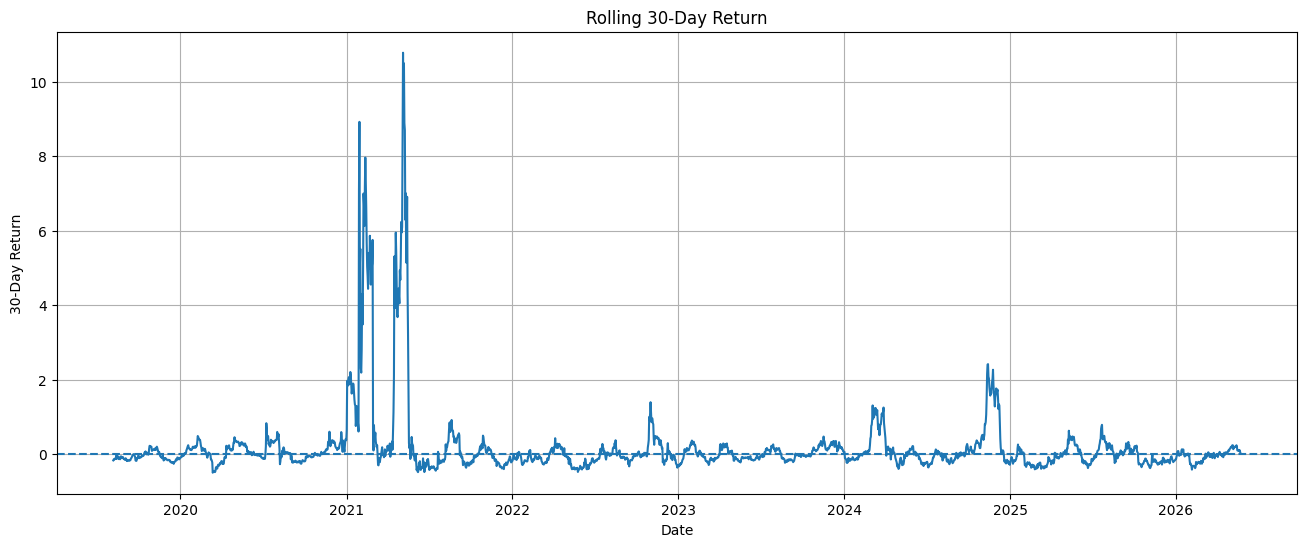

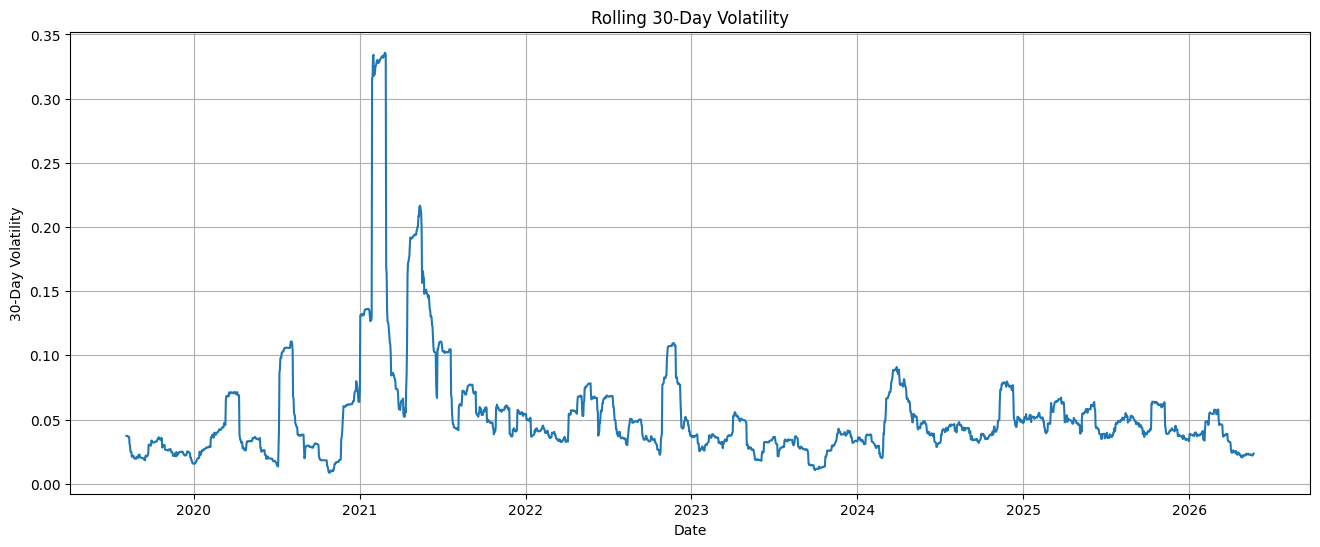

,num_days,percentage
market_regime,,
sideways,695,0.281947
bear,494,0.200406
bull,438,0.177688
bull_high_volatility,400,0.162272
bear_high_volatility,320,0.129817
sideways_high_volatility,118,0.047870


In [13]:
# ============================================================
# Rolling return and rolling volatility regimes
# Analiza ventanas móviles de 30 días para aproximar cambios de régimen en tendencia y volatilidad.
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(daily.index, daily["rolling_30d_return"])
plt.axhline(0, linestyle="--")
plt.title("Rolling 30-Day Return")
plt.xlabel("Date")
plt.ylabel("30-Day Return")
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 6))
plt.plot(daily.index, daily["rolling_30d_volatility"])
plt.title("Rolling 30-Day Volatility")
plt.xlabel("Date")
plt.ylabel("30-Day Volatility")
plt.grid(True)
plt.show()

regime_data = daily[["rolling_30d_return", "rolling_30d_volatility"]].dropna().copy()

return_low = regime_data["rolling_30d_return"].quantile(0.33)
return_high = regime_data["rolling_30d_return"].quantile(0.66)
vol_high = regime_data["rolling_30d_volatility"].quantile(0.66)

def classify_regime(row):
    if row["rolling_30d_return"] >= return_high and row["rolling_30d_volatility"] >= vol_high:
        return "bull_high_volatility"
    if row["rolling_30d_return"] >= return_high:
        return "bull"
    if row["rolling_30d_return"] <= return_low and row["rolling_30d_volatility"] >= vol_high:
        return "bear_high_volatility"
    if row["rolling_30d_return"] <= return_low:
        return "bear"
    if row["rolling_30d_volatility"] >= vol_high:
        return "sideways_high_volatility"
    return "sideways"

regime_data["market_regime"] = regime_data.apply(classify_regime, axis=1)

regime_counts = regime_data["market_regime"].value_counts().to_frame("num_days")
regime_counts["percentage"] = regime_counts["num_days"] / regime_counts["num_days"].sum()

display(regime_counts)


## Conclusiones - Regímenes de mercado

El análisis de retornos y volatilidad en ventanas de 30 días permite aproximar distintos regímenes de mercado: fases alcistas, bajistas, laterales y periodos de alta volatilidad. Esta clasificación no se utiliza como modelo definitivo, sino como herramienta exploratoria para entender la heterogeneidad temporal del dataset.

PENDIENTE DE RESULTADO: revisar qué regímenes predominan y si los periodos de alta volatilidad coinciden con los grandes movimientos observados en el precio. Este análisis puede servir como justificación para incluir filtros de volatilidad y gestión de riesgo en fases posteriores.


Monthly summary


,mean_return,median_return,mean_abs_return,mean_volume,observations
month,,,,,
1,0.000055,0.0,0.002607,1.046682e+07,62496
2,0.000010,0.0,0.002415,9.165480e+06,55169
3,0.000011,0.0,0.002304,5.289091e+06,60679
4,0.000045,0.0,0.002484,9.858094e+06,58606
5,0.000008,0.0,0.002448,6.739452e+06,60027
6,-0.000015,0.0,0.001924,3.765734e+06,51212
7,0.000011,0.0,0.002089,4.448256e+06,60626
8,-0.000003,0.0,0.001808,3.678780e+06,61173
9,-0.000003,0.0,0.001573,2.623842e+06,59964


Weekday summary


,mean_return,median_return,mean_abs_return,mean_volume,observations
weekday,,,,,
0,-0.000004,0.0,0.002234,6.110968e+06,101798
1,0.000002,0.0,0.002186,5.683216e+06,102042
2,0.000018,0.0,0.002218,5.964786e+06,101923
3,0.000017,0.0,0.002239,6.863505e+06,101657
4,0.000033,0.0,0.002267,6.592614e+06,101614
5,0.000027,0.0,0.001905,5.460035e+06,101630
6,0.000004,0.0,0.001913,5.500952e+06,101593


Hourly summary


,mean_return,median_return,mean_abs_return,mean_volume,observations
hour,,,,,
0,0.000012,0.0,0.002485,6.596088e+06,29712
1,0.000020,0.0,0.002194,5.743247e+06,29590
2,0.000009,0.0,0.002060,5.278770e+06,29593
3,0.000016,0.0,0.001956,5.285775e+06,29599
4,0.000046,0.0,0.001924,5.413836e+06,29637
5,0.000036,0.0,0.001855,5.103410e+06,29660
6,-0.000015,0.0,0.001911,5.480159e+06,29662
7,0.000034,0.0,0.001934,5.588467e+06,29676
8,-0.000015,0.0,0.002032,6.031226e+06,29676


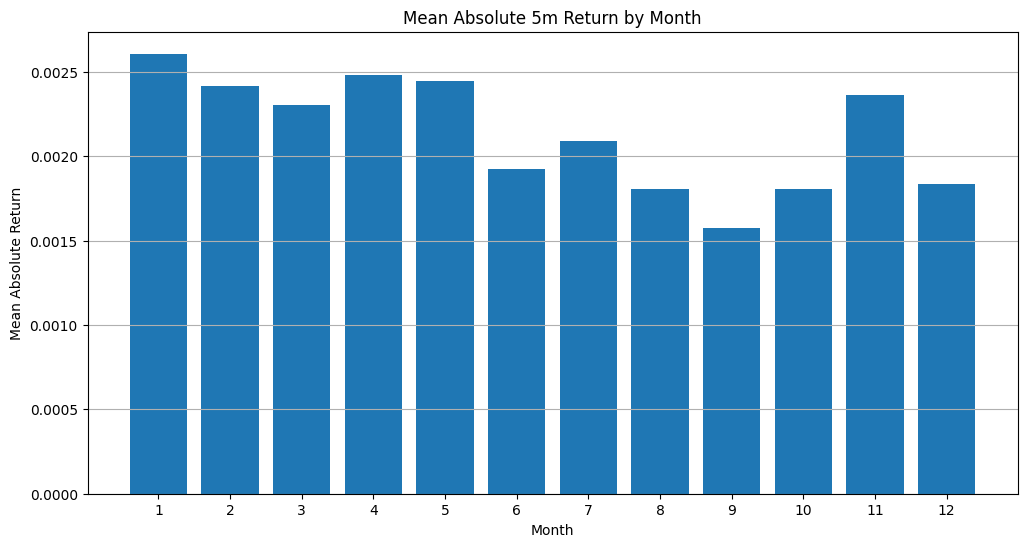

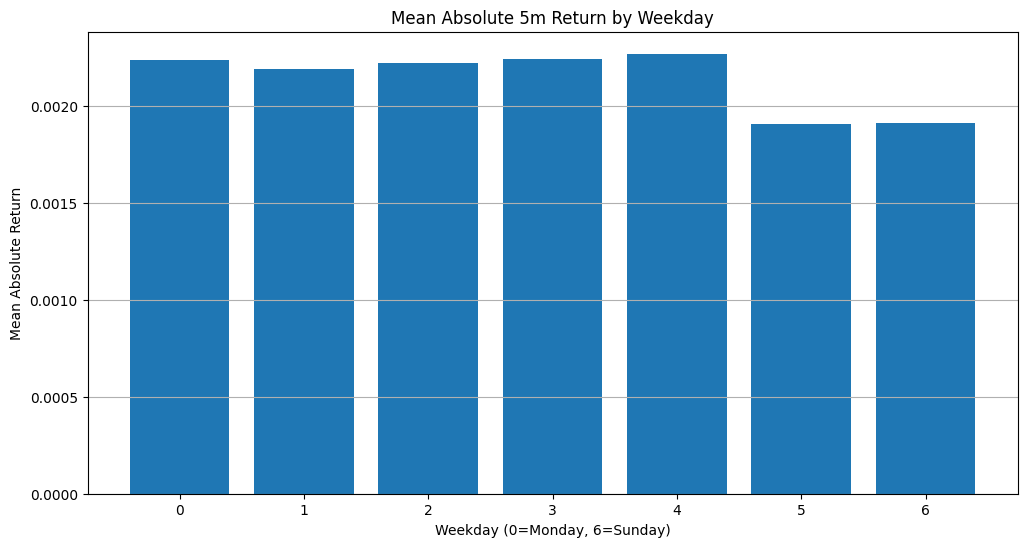

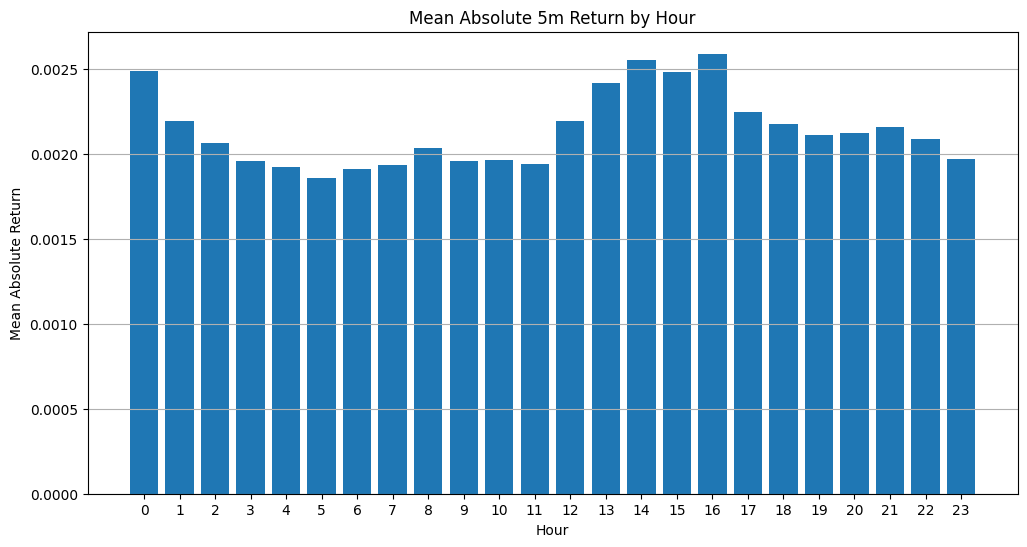

In [14]:
# ============================================================
# Calendar seasonality - month, weekday and hour
# Explora posibles patrones temporales recurrentes en retornos, volatilidad y volumen.
# ============================================================

calendar_df = df_eda.copy()
calendar_df["year"] = calendar_df["open_time"].dt.year
calendar_df["month"] = calendar_df["open_time"].dt.month
calendar_df["weekday"] = calendar_df["open_time"].dt.dayofweek
calendar_df["hour"] = calendar_df["open_time"].dt.hour
calendar_df["abs_return_prev_1"] = calendar_df["return_prev_1"].abs()

monthly_summary = calendar_df.groupby("month").agg(
    mean_return=("return_prev_1", "mean"),
    median_return=("return_prev_1", "median"),
    mean_abs_return=("abs_return_prev_1", "mean"),
    mean_volume=("volume", "mean"),
    observations=("return_prev_1", "size")
)

weekday_summary = calendar_df.groupby("weekday").agg(
    mean_return=("return_prev_1", "mean"),
    median_return=("return_prev_1", "median"),
    mean_abs_return=("abs_return_prev_1", "mean"),
    mean_volume=("volume", "mean"),
    observations=("return_prev_1", "size")
)

hourly_summary = calendar_df.groupby("hour").agg(
    mean_return=("return_prev_1", "mean"),
    median_return=("return_prev_1", "median"),
    mean_abs_return=("abs_return_prev_1", "mean"),
    mean_volume=("volume", "mean"),
    observations=("return_prev_1", "size")
)

print("Monthly summary")
display(monthly_summary)

print("Weekday summary")
display(weekday_summary)

print("Hourly summary")
display(hourly_summary)

plt.figure(figsize=(12, 6))
plt.bar(monthly_summary.index.astype(str), monthly_summary["mean_abs_return"])
plt.title("Mean Absolute 5m Return by Month")
plt.xlabel("Month")
plt.ylabel("Mean Absolute Return")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(weekday_summary.index.astype(str), weekday_summary["mean_abs_return"])
plt.title("Mean Absolute 5m Return by Weekday")
plt.xlabel("Weekday (0=Monday, 6=Sunday)")
plt.ylabel("Mean Absolute Return")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(hourly_summary.index.astype(str), hourly_summary["mean_abs_return"])
plt.title("Mean Absolute 5m Return by Hour")
plt.xlabel("Hour")
plt.ylabel("Mean Absolute Return")
plt.grid(True, axis="y")
plt.show()


## Conclusiones - Seasonality de calendario

Este análisis explora si existen diferencias sistemáticas según mes, día de la semana u hora del día. En criptomonedas, al tratarse de mercados que operan 24/7, los patrones horarios y semanales pueden diferir de los mercados financieros tradicionales.

Es importante no confundir este análisis con los grandes ciclos alcistas del mercado. Los bull runs reflejan cambios de régimen de largo plazo, mientras que la seasonality de calendario busca patrones repetitivos asociados a unidades temporales concretas.

PENDIENTE DE RESULTADO: revisar si alguna franja horaria, día o mes muestra mayor volatilidad o volumen medio. Si las diferencias son pequeñas, conviene presentarlo como evidencia débil o exploratoria, no como una regla de trading.


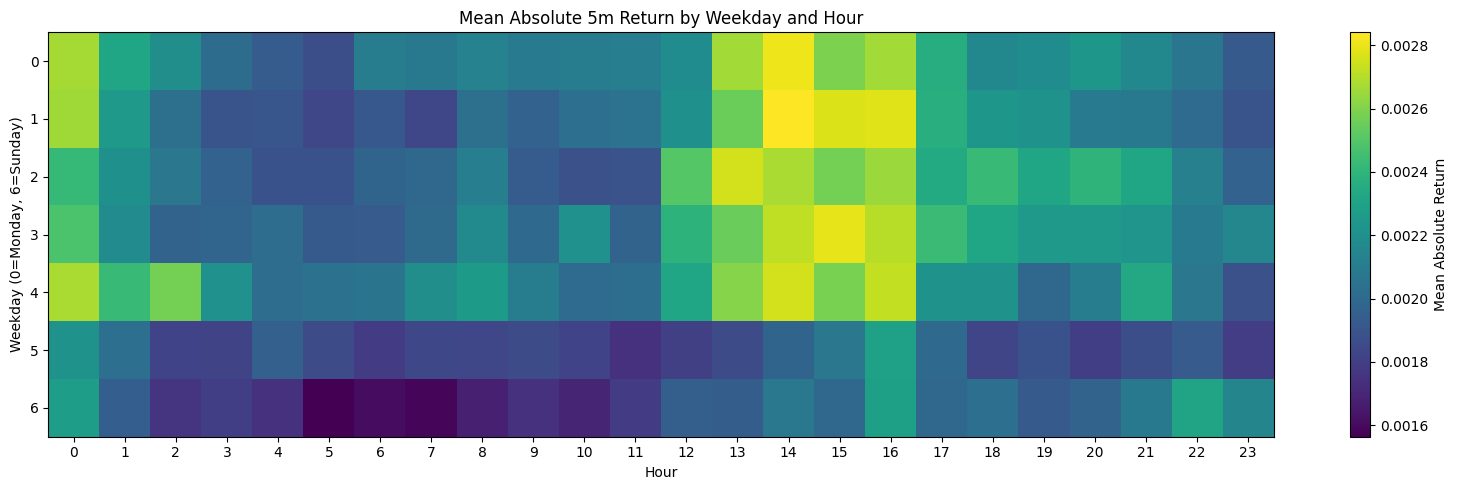

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,,,,
0,0.002669,0.002317,0.002195,0.002016,0.001935,0.001870,0.002102,0.002082,0.002128,0.002093,0.002105,0.002112,0.002185,0.002661,0.002810,0.002591,0.002666,0.002362,0.002159,0.002184,0.002237,0.002161,0.002063,0.001927
1,0.002658,0.002251,0.002033,0.001896,0.001903,0.001838,0.001916,0.001837,0.002038,0.001963,0.002033,0.002050,0.002207,0.002554,0.002841,0.002774,0.002780,0.002370,0.002238,0.002221,0.002084,0.002080,0.002011,0.001894
2,0.002420,0.002202,0.002069,0.001963,0.001888,0.001884,0.001975,0.001993,0.002110,0.001937,0.001881,0.001891,0.002502,0.002752,0.002677,0.002571,0.002651,0.002342,0.002422,0.002317,0.002394,0.002317,0.002118,0.001965
3,0.002479,0.002182,0.001969,0.001980,0.002019,0.001923,0.001929,0.002005,0.002175,0.002000,0.002211,0.001969,0.002390,0.002549,0.002720,0.002795,0.002705,0.002434,0.002320,0.002247,0.002249,0.002230,0.002088,0.002156
4,0.002679,0.002429,0.002573,0.002211,0.002021,0.002047,0.002056,0.002195,0.002262,0.002107,0.002009,0.002025,0.002316,0.002611,0.002754,0.002582,0.002721,0.002220,0.002216,0.001990,0.002100,0.002336,0.002069,0.001879
5,0.002216,0.002028,0.001823,0.001828,0.001957,0.001857,0.001791,0.001842,0.001836,0.001856,0.001821,0.001744,0.001805,0.001857,0.001977,0.002070,0.002297,0.002002,0.001832,0.001884,0.001800,0.001873,0.001929,0.001795
6,0.002277,0.001947,0.001761,0.001799,0.001746,0.001564,0.001608,0.001582,0.001677,0.001745,0.001696,0.001785,0.001952,0.001941,0.002074,0.001989,0.002292,0.001993,0.002032,0.001926,0.001971,0.002081,0.002308,0.002144


In [15]:
# ============================================================
# Hour-weekday volatility heatmap
# Visualiza la volatilidad media por hora y día de la semana para detectar patrones intradía o semanales.
# ============================================================

heatmap_data = calendar_df.pivot_table(
    index="weekday",
    columns="hour",
    values="abs_return_prev_1",
    aggfunc="mean"
)

plt.figure(figsize=(16, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.title("Mean Absolute 5m Return by Weekday and Hour")
plt.xlabel("Hour")
plt.ylabel("Weekday (0=Monday, 6=Sunday)")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label="Mean Absolute Return")
plt.tight_layout()
plt.show()

display(heatmap_data)


## Conclusiones - Heatmap horario-semanal

El heatmap permite detectar si la volatilidad media se concentra en determinados momentos de la semana. Este análisis puede resultar útil para interpretar cuándo el mercado presenta mayor actividad o mayor riesgo operativo.

PENDIENTE DE RESULTADO: identificar visualmente si existen bloques horarios o días con volatilidad superior a la media. Si el patrón no es claro, debe interpretarse como ausencia de seasonality fuerte en esta escala.


In [16]:
# ============================================================
# Stationarity tests on daily series
# Aplica ADF y KPSS sobre precio logarítmico diario y retornos diarios para diferenciar serie de precios y serie de retornos.
# ============================================================

try:
    from statsmodels.tsa.stattools import adfuller, kpss

    def stationarity_tests(series, name):
        clean_series = series.dropna().astype(float)

        adf_result = adfuller(clean_series, autolag="AIC")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_result = kpss(clean_series, regression="c", nlags="auto")

        return {
            "series": name,
            "n_obs": len(clean_series),
            "adf_statistic": adf_result[0],
            "adf_pvalue": adf_result[1],
            "kpss_statistic": kpss_result[0],
            "kpss_pvalue": kpss_result[1]
        }

    stationarity_df = pd.DataFrame([
        stationarity_tests(np.log(daily["close"]), "daily_log_close"),
        stationarity_tests(daily["daily_log_return"], "daily_log_return")
    ])

    display(stationarity_df)

except ImportError:
    print("statsmodels is not installed. Install statsmodels to run ADF and KPSS tests.")


,series,n_obs,adf_statistic,adf_pvalue,kpss_statistic,kpss_pvalue
0,daily_log_close,2495,-1.831925,3.647308e-01,4.500206,0.01
1,daily_log_return,2494,-8.698306,3.870592e-14,0.218335,0.10


## Conclusiones - Stationarity

Las pruebas de stationarity ayudan a distinguir entre el comportamiento del precio y el de los retornos. En series financieras suele ocurrir que el precio no sea stationary, mientras que los retornos presentan un comportamiento más cercano a la stationarity, aunque con volatilidad cambiante y colas pesadas.

La prueba ADF contrasta la presencia de raíz unitaria, mientras que KPSS parte de la hipótesis opuesta: que la serie es stationary alrededor de una media o tendencia. Usar ambas pruebas permite obtener una lectura más robusta.

PENDIENTE DE RESULTADO: interpretar los p-values obtenidos. Si el log-precio no es stationary y los retornos sí muestran mayor stationarity, esto refuerza la decisión de modelar retornos, indicadores y targets derivados en lugar del precio bruto directamente.


,lag,return_autocorrelation,squared_return_autocorrelation
0,1,-0.047191,0.392067
1,2,-0.019636,0.208532
2,3,0.002985,0.146199
3,4,0.006315,0.137343
4,5,-0.016912,0.141737
5,6,-0.016097,0.100613
6,7,0.003411,0.090404
7,8,0.006376,0.095173
8,9,-0.001957,0.077396
9,10,-0.002580,0.075801


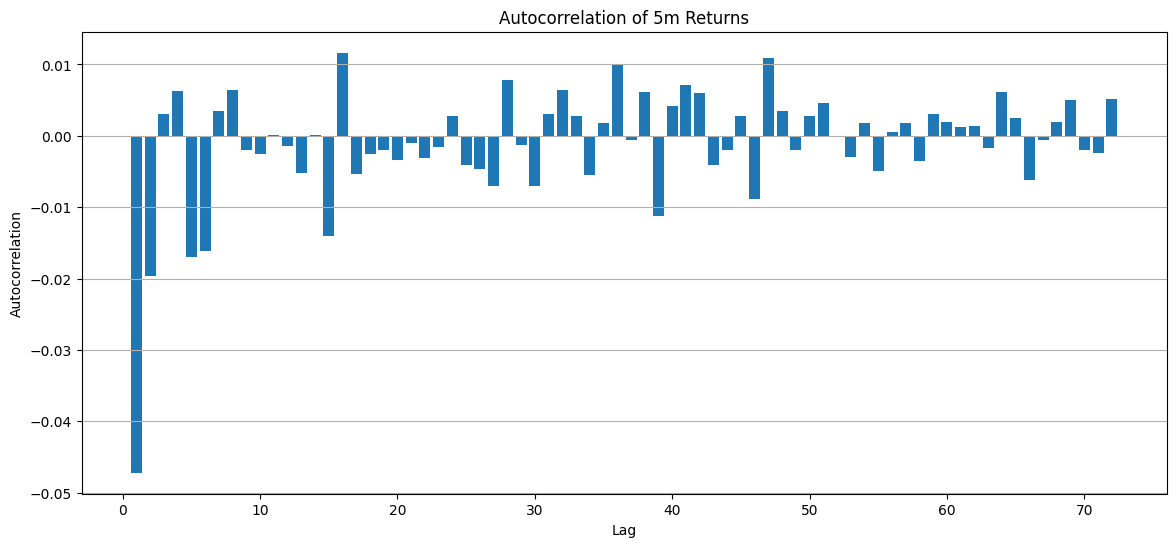

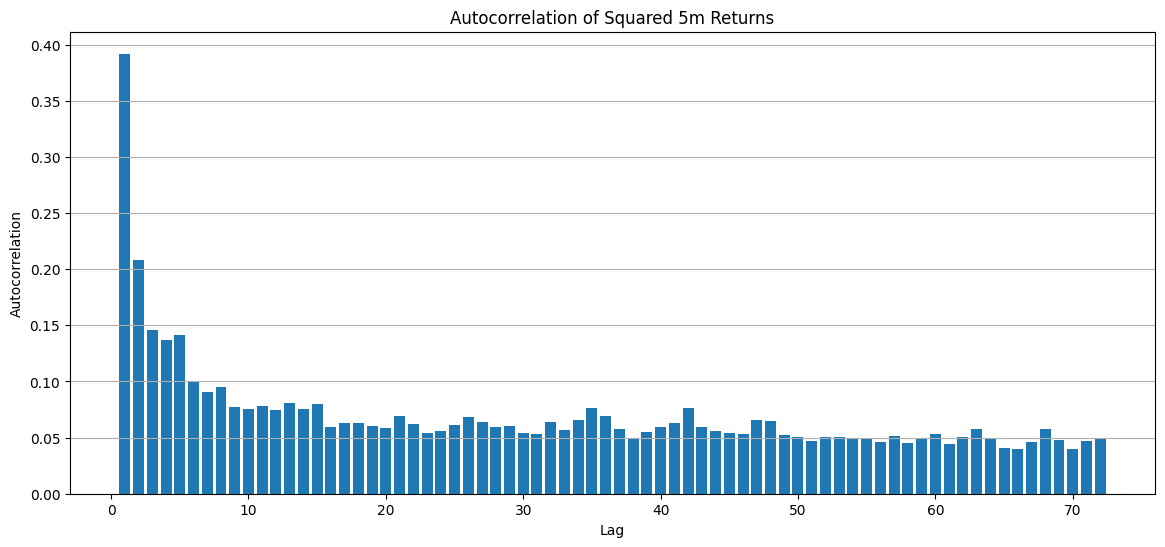

In [17]:
# ============================================================
# Autocorrelation of returns and squared returns
# Compara la autocorrelación de retornos con la autocorrelación de retornos al cuadrado para detectar posible volatility clustering.
# ============================================================

max_lag = 72
returns_5m = df_eda["return_prev_1"].dropna()
squared_returns_5m = returns_5m ** 2

acf_returns = [returns_5m.autocorr(lag=lag) for lag in range(1, max_lag + 1)]
acf_squared_returns = [squared_returns_5m.autocorr(lag=lag) for lag in range(1, max_lag + 1)]

acf_df = pd.DataFrame({
    "lag": range(1, max_lag + 1),
    "return_autocorrelation": acf_returns,
    "squared_return_autocorrelation": acf_squared_returns
})

display(acf_df.head(20))

plt.figure(figsize=(14, 6))
plt.bar(acf_df["lag"], acf_df["return_autocorrelation"])
plt.title("Autocorrelation of 5m Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(acf_df["lag"], acf_df["squared_return_autocorrelation"])
plt.title("Autocorrelation of Squared 5m Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, axis="y")
plt.show()


## Conclusiones - Autocorrelación y volatility clustering

La autocorrelación de retornos permite evaluar si los movimientos de precio presentan dependencia lineal directa entre velas. En mercados eficientes, esta autocorrelación suele ser baja en retornos simples.

Sin embargo, la autocorrelación de retornos al cuadrado puede revelar volatility clustering, es decir, periodos donde la volatilidad alta tiende a agruparse temporalmente. Este fenómeno es habitual en series financieras y justifica el uso de variables dinámicas de volatilidad como `volatility_1h` o `atr_14`.

PENDIENTE DE RESULTADO: comprobar si los retornos simples presentan autocorrelación baja y si los retornos al cuadrado mantienen autocorrelación positiva durante varios lags.


,target,class_0,class_1,num_observations
0,up_1,0.529937,0.470063,712257
1,up_3,0.509744,0.490256,712257
2,up_6,0.504992,0.495008,712257
3,up_12,0.502576,0.497424,712257


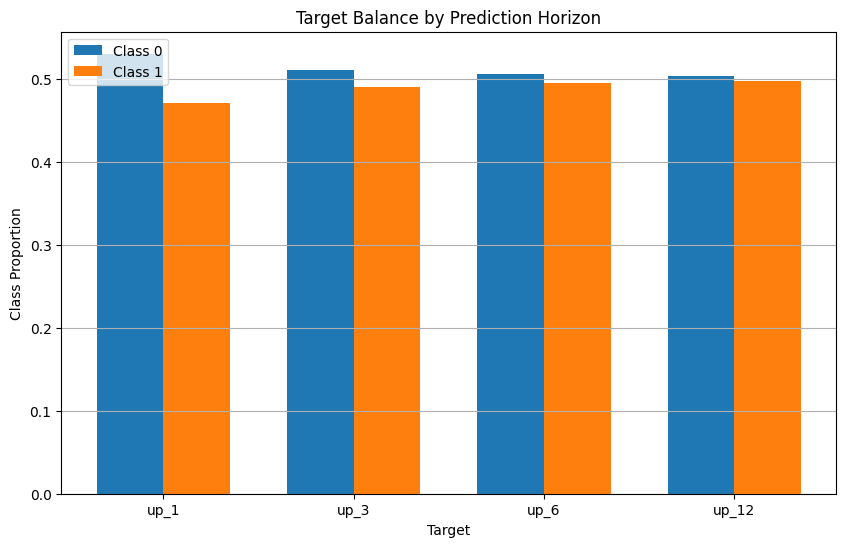

In [18]:
# ============================================================
# Multi-horizon target balance
# Compara el balance de clases para los distintos horizontes supervisados generados en feature engineering.
# ============================================================

target_cols = [col for col in ["up_1", "up_3", "up_6", "up_12"] if col in df.columns]

target_balance = []

for col in target_cols:
    counts = df[col].value_counts(normalize=True).sort_index()
    target_balance.append({
        "target": col,
        "class_0": counts.get(0, np.nan),
        "class_1": counts.get(1, np.nan),
        "num_observations": df[col].notna().sum()
    })

target_balance_df = pd.DataFrame(target_balance)
display(target_balance_df)

plt.figure(figsize=(10, 6))
positions = np.arange(len(target_balance_df))
width = 0.35

plt.bar(positions - width / 2, target_balance_df["class_0"], width, label="Class 0")
plt.bar(positions + width / 2, target_balance_df["class_1"], width, label="Class 1")

plt.xticks(positions, target_balance_df["target"])
plt.title("Target Balance by Prediction Horizon")
plt.xlabel("Target")
plt.ylabel("Class Proportion")
plt.legend()
plt.grid(True, axis="y")
plt.show()


## Conclusiones - Balance de targets por horizonte

Comparar los targets en varios horizontes permite comprobar si el problema supervisado mantiene una distribución razonablemente equilibrada cuando se amplía la ventana futura de predicción.

PENDIENTE DE RESULTADO: confirmar si los targets `up_1`, `up_3`, `up_6` y `up_12` mantienen un balance cercano entre clases. Si aparecen desequilibrios relevantes en algún horizonte, deberán tenerse en cuenta al seleccionar métricas de evaluación.


Top absolute correlations with future_return_1


,correlation
log_return_prev_1,-0.052272
return_prev_1,-0.047218
volume,0.039062
volatility_1h,0.037714
taker_buy_base_asset_volume,0.034732
bb_width,0.032622
macd_hist,-0.025274
dist_to_nearest_resistance,0.024800
macd,-0.022822
number_of_trades,0.020672


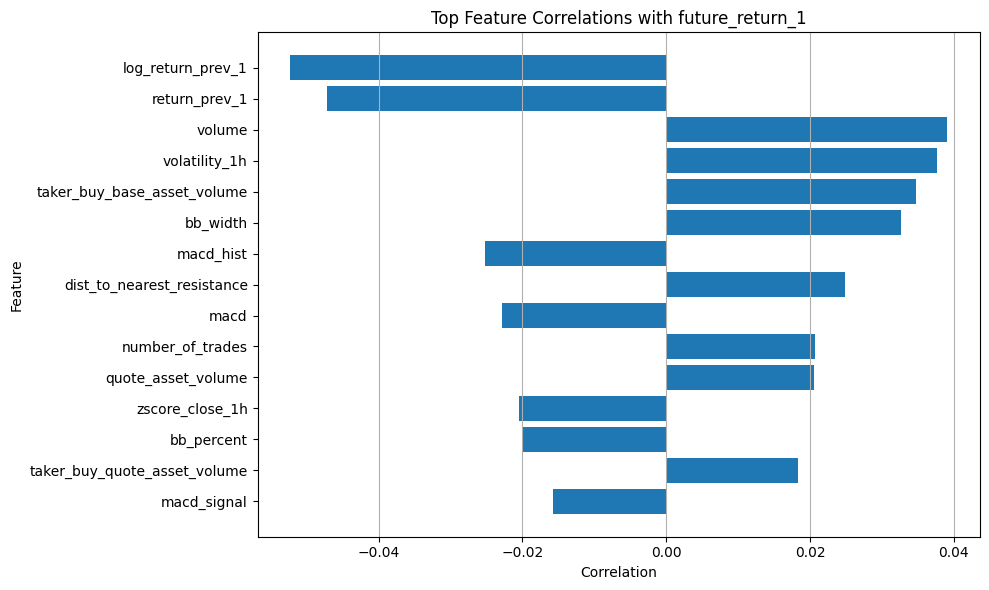

Top absolute correlations with future_return_3


,correlation
volume,0.053694
volatility_1h,0.052416
taker_buy_base_asset_volume,0.050285
bb_width,0.049617
log_return_prev_1,-0.041995
return_prev_1,-0.037253
dist_to_nearest_resistance,0.033716
macd_hist,-0.033403
macd,-0.033156
dist_to_nearest_support,0.026358


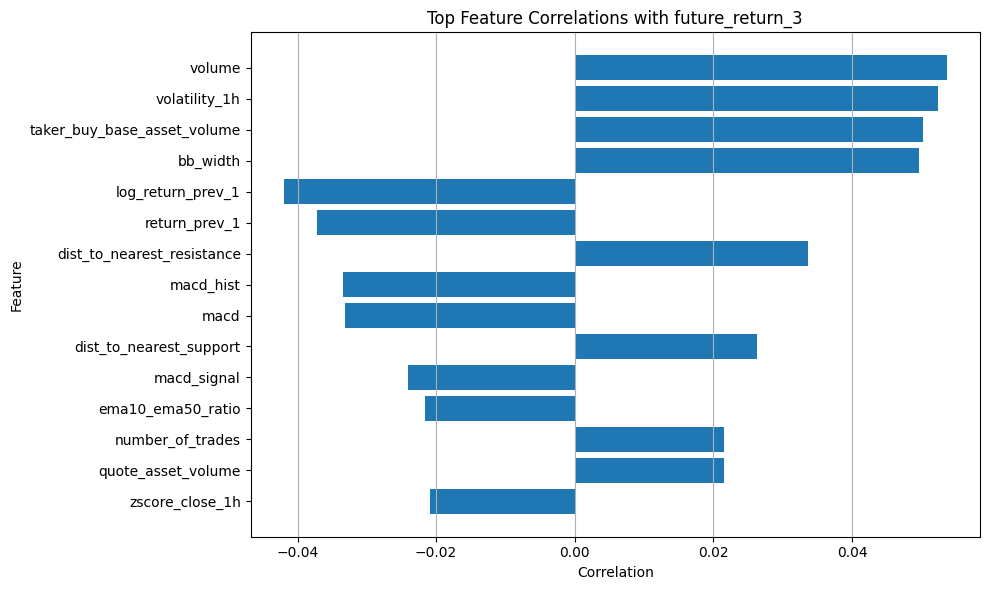

Top absolute correlations with future_return_6


,correlation
volatility_1h,0.067789
bb_width,0.062645
volume,0.061672
taker_buy_base_asset_volume,0.060320
dist_to_nearest_resistance,0.044133
log_return_prev_1,-0.042626
macd_hist,-0.042510
macd,-0.041343
return_prev_1,-0.037850
dist_to_nearest_support,0.037424


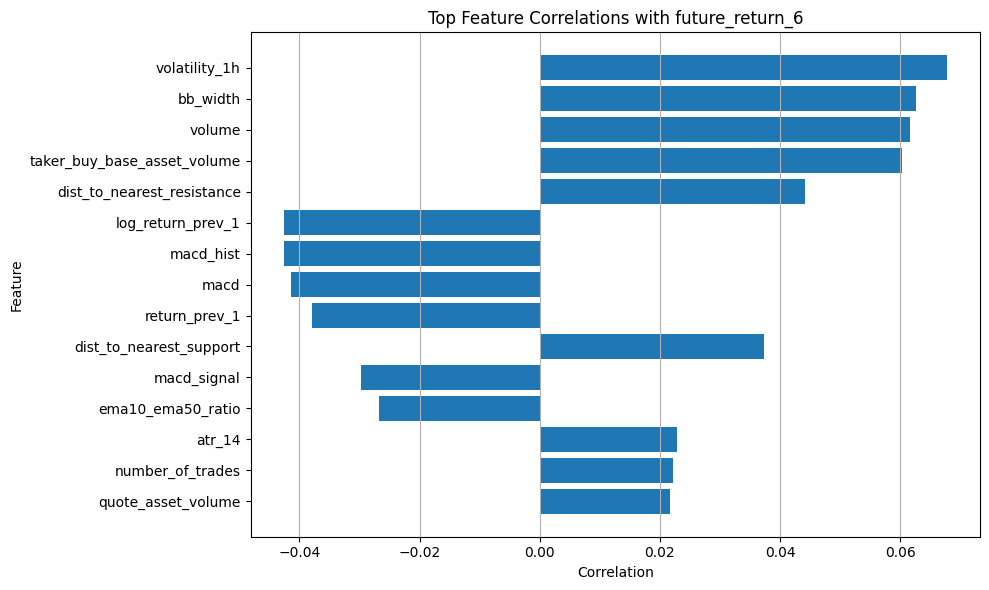

Top absolute correlations with future_return_12


,correlation
volatility_1h,0.082565
volume,0.076435
taker_buy_base_asset_volume,0.075956
bb_width,0.070104
dist_to_nearest_support,0.054443
dist_to_nearest_resistance,0.051810
macd,-0.041235
macd_hist,-0.038970
ema50_ema200_ratio,0.033997
macd_signal,-0.030857


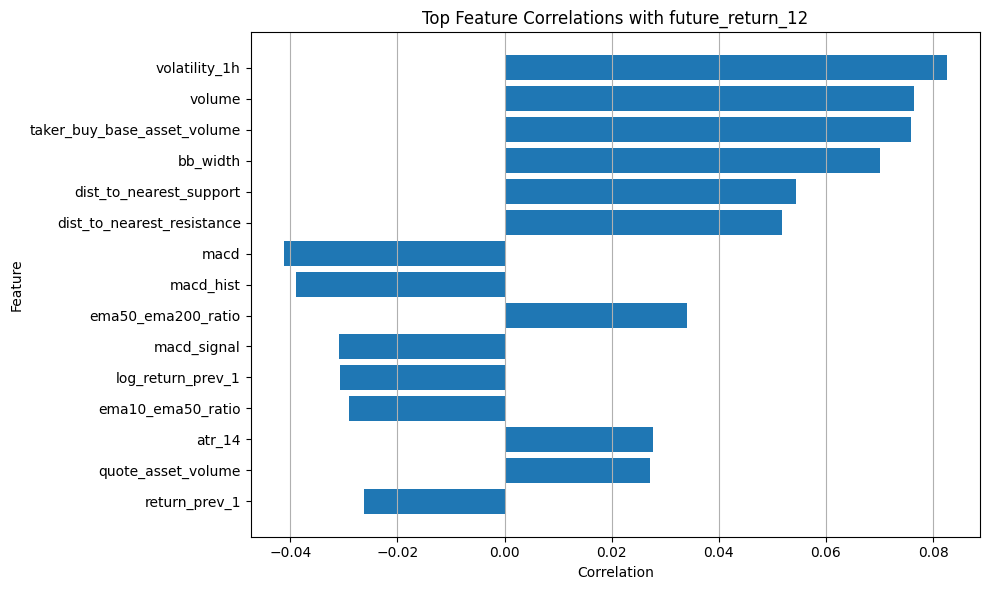

Top absolute correlations with up_1


,correlation
bb_percent,-0.068104
zscore_close_1h,-0.067971
rsi_14,-0.053500
log_return_prev_1,-0.034658
return_prev_1,-0.034567
ema_200,0.031692
ema_50,0.031648
recent_resistance,0.031595
bb_upper,0.031574
recent_support,0.031561


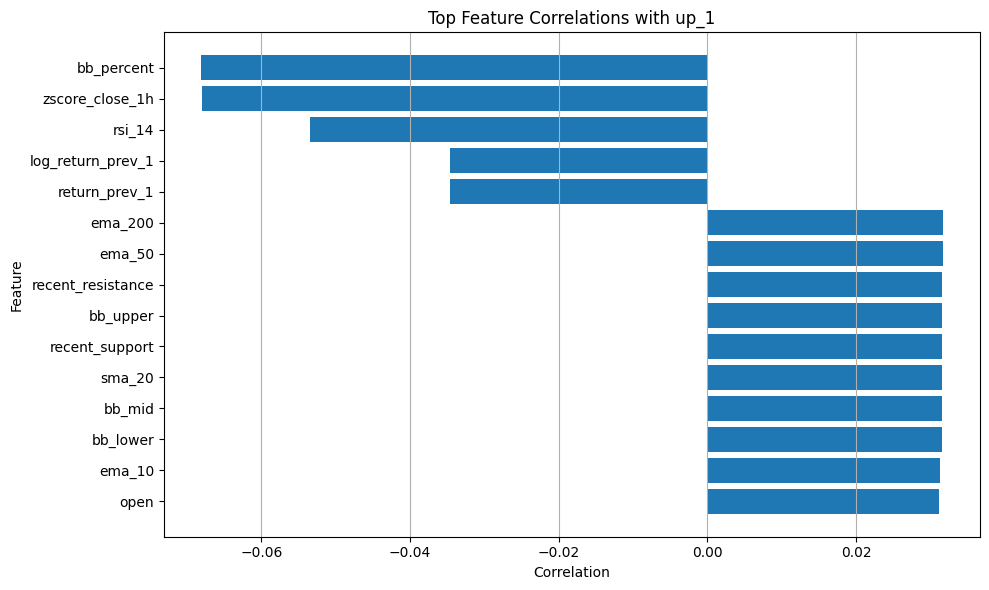

In [19]:
# ============================================================
# Feature-target correlation screening
# Calcula correlaciones simples entre variables explicativas y targets para obtener una primera lectura exploratoria de señal predictiva.
# ============================================================

exclude_patterns = [
    "future_close_",
    "future_return_",
    "up_"
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

candidate_feature_cols = [
    col for col in numeric_cols
    if not any(col.startswith(pattern) for pattern in exclude_patterns)
]

correlation_targets = [col for col in ["future_return_1", "future_return_3", "future_return_6", "future_return_12", "up_1"] if col in df.columns]

feature_target_corr = df[candidate_feature_cols + correlation_targets].corr()[correlation_targets].loc[candidate_feature_cols]

for target in correlation_targets:
    print(f"Top absolute correlations with {target}")
    top_corr = (
        feature_target_corr[target]
        .dropna()
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .head(15)
        .to_frame("correlation")
    )
    display(top_corr)

    plt.figure(figsize=(10, 6))
    plt.barh(top_corr.index[::-1], top_corr["correlation"][::-1])
    plt.title(f"Top Feature Correlations with {target}")
    plt.xlabel("Correlation")
    plt.ylabel("Feature")
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.show()


## Conclusiones - Correlación entre features y targets

Este análisis no pretende seleccionar variables de forma definitiva, pero proporciona una primera aproximación a la relación lineal entre las features generadas y los targets supervisados. En trading es habitual que las correlaciones lineales simples sean débiles, incluso cuando algunas variables pueden aportar información útil dentro de modelos no lineales o combinadas con otras features.

PENDIENTE DE RESULTADO: revisar si alguna familia de variables aparece de forma recurrente entre las correlaciones más altas. Si las correlaciones son bajas, debe interpretarse como señal de que el problema predictivo es difícil y no como un fallo directo del pipeline.


In [20]:
# ============================================================
# Final EDA summary helpers
# Genera un resumen compacto de métricas clave para trasladar a la memoria del TFM.
# ============================================================

eda_summary = {
    "dataset_rows": df.shape[0],
    "dataset_columns": df.shape[1],
    "start_date": df["open_time"].min(),
    "end_date": df["open_time"].max(),
    "return_skewness": df["return_prev_1"].skew(),
    "return_kurtosis": df["return_prev_1"].kurtosis(),
    "max_drawdown_daily_close": daily["drawdown"].min(),
    "target_up_1_class_0": df["up_1"].value_counts(normalize=True).sort_index().get(0, np.nan),
    "target_up_1_class_1": df["up_1"].value_counts(normalize=True).sort_index().get(1, np.nan),
}

eda_summary_df = pd.DataFrame.from_dict(eda_summary, orient="index", columns=["value"])
display(eda_summary_df)


,value
dataset_rows,712257
dataset_columns,54
start_date,2019-07-07 11:50:00
end_date,2026-05-23 10:10:00
return_skewness,0.202438
return_kurtosis,398.069604
max_drawdown_daily_close,-0.923313
target_up_1_class_0,0.529937
target_up_1_class_1,0.470063


## Conclusiones finales del EDA v2

El EDA ampliado permite caracterizar el dataset desde varias perspectivas complementarias: evolución de precio, distribución de retornos, volatilidad, indicadores técnicos, balance de targets, patrones temporales, stationarity, autocorrelación y correlaciones exploratorias entre features y targets.

Los resultados deben interpretarse como una fase de diagnóstico previa al modelado, no como una estrategia de trading por sí mismos. Su función principal es identificar propiedades relevantes del mercado DOGE/USDT, detectar posibles riesgos metodológicos y justificar decisiones posteriores del pipeline.

PENDIENTE DE RESULTADO: una vez ejecutado el notebook completo, actualizar esta conclusión con los hallazgos concretos más relevantes y trasladar a la memoria únicamente los análisis con mayor valor explicativo.
